### Import Modules

In [15]:
import pandas as pd,numpy as np,json
import getpass,os
from langchain.chat_models import init_chat_model
from ai_patterns_mining import parse_json_safe
from langchain.agents import create_agent
from pydantic import BaseModel,Field
from langchain.tools import tool
from langchain.agents.middleware import dynamic_prompt,ModelRequest
from langchain.agents.structured_output import ToolStrategy
from tqdm import tqdm
from time import time,sleep
from umap import UMAP
from sklearn.cluster import DBSCAN
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

### Initialize LLM

In [7]:
if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

llm = init_chat_model("gemini-2.5-flash", model_provider="google_genai", temperature=1)

In [76]:
class SummarizationOutput(BaseModel):
    summary: str = Field(..., description="A concise two-sentence summary of the micro-architecture.")

@tool
def extract_representative_sentences(description: str) -> str:
    """
    Select the two most representative ORIGINAL sentences from the description.
    """
    print("Extracting representative sentences...")
    return f"""
From the description below, select exactly two sentences that best represent the core micro-architecture idea. 
Rules:
- Select only original sentences from the text.
- Do not rewrite, paraphrase, or summarize.
- Output ONLY the two sentences.

Description:
{description}
"""

@tool
def summarize_micro_architecture(description: str) -> str:
    """
    Summarize the micro-architecture in exactly two sentences.
    """
    print("Summarizing micro-architecture...")
    return f"""
Summarize the micro-architecture described below in exactly two sentences.
Rules:
- Output exactly 2 sentences.
- Focus on the architecture flow, components, and behavior.
- No bullet points, no extra text.

Description:
{description}

Two-sentence summary:
"""

@tool
def validate_extracted_sentences(text: str) -> str:
    """
    Validate extraction: must be exactly two sentences from the original text. if not, regenerate.
    """
    print("Validating extracted sentences...")
    return f"""Validate below text contains exactly two sentences:
    {text}
    """

@tool
def validate_two_sentence_summary(text: str) -> str:
    """
    Validate summary: must be exactly 2 sentences.
    """
    print("Validating two-sentence summary...")
    return f"""Validate below text contains exactly two sentences:
    {text}
    """

class DescriptionExtractionAgent:
    def __init__(self, llm):
        self.llm = llm
        self.agent = create_agent(
            llm,
            system_prompt=(
                "You are an extraction agent. Your job is to extract the two most "
                "representative original sentences from the description. After generation, "
                "you must validate and regenerate until valid."
            ),
            tools=[extract_representative_sentences, validate_extracted_sentences],
            response_format=ToolStrategy(SummarizationOutput)
        )

    def run(self, description: str):
        result = self.agent.invoke({"messages": [
                {"role": "user", "content": description}
            ]},recursion_limit=50)
        retry_count = 0
        while 'structured_response' not in result:
            if retry_count > 5:
                raise Exception("Max retries exceeded for description extraction.")
            sleep(1)
            result = self.agent.run({"messages": [
                {"role": "user", "content": description}
            ]})
            print(" - retrying description extraction...", end="\r")
            retry_count += 1
        return result['structured_response']

class MicroArchitectureSummaryAgent:
    def __init__(self, llm):
        self.llm = llm
        self.agent = create_agent(
            llm,
            system_prompt=(
                "You are a micro-architecture summarization agent. Your job is to produce a "
                "two-sentence summary that captures the architectural idea. You must validate "
                "your output and regenerate until valid."
            ),
            tools=[summarize_micro_architecture, validate_two_sentence_summary],
            response_format=ToolStrategy(SummarizationOutput)
        )

    def run(self, description: str):
        result = self.agent.invoke({"messages": [
                {"role": "user", "content": description}
            ]},recursion_limit=50)
        retry_count = 0
        while 'structured_response' not in result:
            if retry_count > 5:
                raise Exception("Max retries exceeded for description extraction.")
            sleep(1)
            result = self.agent.invoke({"messages": [
                {"role": "user", "content": description}
            ]})
            print(" - retrying micro-architecture summarization...", end="\r")
            retry_count += 1
        return result['structured_response']


### Import data

In [9]:
community_data = pd.read_csv("../data/raw/repos/embeddings_call_graph_clusters_v2.csv")
community_data['code_file'] = community_data['cluster_file'].apply(lambda x: x.replace('./result/repo_callgraph_clusters/', ''))

descriptions = json.load(open('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/notebooks/result/predicted_clusters_verification_results_with_descriptions.json'))
community_data['code_description'] = community_data['code_file'].apply(lambda x: descriptions.get(x, {}).get('code_summary', ""))
community_data = community_data[community_data['code_description'] != ""]

community_feature_cols = [i for i in community_data.columns if i.startswith('dim_')]
community_embeddings = community_data[community_feature_cols].to_numpy()

In [10]:
community_data.shape

(1679, 771)

### Clustering

In [58]:
scaler = StandardScaler()
community_embeddings_scaled = scaler.fit_transform(community_embeddings)
umap_model = UMAP(n_components=50,n_neighbors=15,metric='cosine', random_state=42)
community_embeddings_umap = umap_model.fit_transform(community_embeddings_scaled)

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [6]:
model = AgglomerativeClustering(
    n_clusters=100,
    # metric='cosine',
    # distance_threshold=0.5,  # Set to None if you want to specify n_clusters
    linkage='average'   # other options: 'complete', 'average', 'single'
)
cluster_labels = model.fit_predict(community_embeddings_umap)
community_data['cluster_label'] = cluster_labels

for i in set(cluster_labels):
    cluster_size = community_data[community_data['cluster_label'] == i].shape[0]
    print(f"Cluster {i}: Size {cluster_size}")

Cluster 0: Size 32
Cluster 1: Size 31
Cluster 2: Size 54
Cluster 3: Size 20
Cluster 4: Size 45
Cluster 5: Size 21
Cluster 6: Size 27
Cluster 7: Size 32
Cluster 8: Size 29
Cluster 9: Size 9
Cluster 10: Size 33
Cluster 11: Size 31
Cluster 12: Size 11
Cluster 13: Size 13
Cluster 14: Size 34
Cluster 15: Size 25
Cluster 16: Size 15
Cluster 17: Size 33
Cluster 18: Size 7
Cluster 19: Size 26
Cluster 20: Size 10
Cluster 21: Size 18
Cluster 22: Size 35
Cluster 23: Size 36
Cluster 24: Size 16
Cluster 25: Size 6
Cluster 26: Size 16
Cluster 27: Size 16
Cluster 28: Size 12
Cluster 29: Size 27
Cluster 30: Size 18
Cluster 31: Size 11
Cluster 32: Size 11
Cluster 33: Size 27
Cluster 34: Size 41
Cluster 35: Size 9
Cluster 36: Size 13
Cluster 37: Size 22
Cluster 38: Size 14
Cluster 39: Size 14
Cluster 40: Size 42
Cluster 41: Size 21
Cluster 42: Size 16
Cluster 43: Size 26
Cluster 44: Size 2
Cluster 45: Size 14
Cluster 46: Size 17
Cluster 47: Size 6
Cluster 48: Size 24
Cluster 49: Size 22
Cluster 50: Size

In [80]:
extraction_agent = DescriptionExtractionAgent(llm)
summary_agent = MicroArchitectureSummaryAgent(llm)

code_cluster_descriptions_file = '/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/notebooks/result/descriptions_for_clustered_communities_v3-hdbscan.json'
if os.path.exists(code_cluster_descriptions_file):
    code_cluster_descriptions = json.load(open(code_cluster_descriptions_file))
else:
    code_cluster_descriptions = {}
for label in np.unique(cluster_labels):
    print(f"\nCluster {label} summaries:")
    if str(label) in code_cluster_descriptions:
        print(" - Using cached summaries.")
        continue
    cluster_descriptions = community_data[community_data['cluster_label'] == label]['code_description'].tolist()
    print(f"Number of code snippets in cluster: {len(cluster_descriptions)}")
    combined_description = "\n\n".join(cluster_descriptions)
    summary1 = extraction_agent.run(combined_description)
    summary2 = summary_agent.run(combined_description)
    
    code_cluster_descriptions[str(label)] = {
        "cluster_id": 'cluster_'+str(label),
        "prompt_01_desc": summary1.summary,
        "prompt_02_desc": summary2.summary,
        "descriptions": "\n\n".join(cluster_descriptions),
    }
    json.dump(code_cluster_descriptions, open(code_cluster_descriptions_file, 'w'), indent=4)


Cluster -1 summaries:
 - Using cached summaries.

Cluster 0 summaries:
 - Using cached summaries.

Cluster 1 summaries:
 - Using cached summaries.

Cluster 2 summaries:
 - Using cached summaries.

Cluster 3 summaries:
 - Using cached summaries.

Cluster 4 summaries:
 - Using cached summaries.

Cluster 5 summaries:
 - Using cached summaries.

Cluster 6 summaries:
 - Using cached summaries.

Cluster 7 summaries:
 - Using cached summaries.

Cluster 8 summaries:
 - Using cached summaries.

Cluster 9 summaries:
 - Using cached summaries.

Cluster 10 summaries:
 - Using cached summaries.

Cluster 11 summaries:
 - Using cached summaries.

Cluster 12 summaries:
 - Using cached summaries.

Cluster 13 summaries:
 - Using cached summaries.

Cluster 14 summaries:
 - Using cached summaries.

Cluster 15 summaries:
 - Using cached summaries.

Cluster 16 summaries:
 - Using cached summaries.

Cluster 17 summaries:
 - Using cached summaries.

Cluster 18 summaries:
 - Using cached summaries.

Cluster 1

KeyboardInterrupt: 

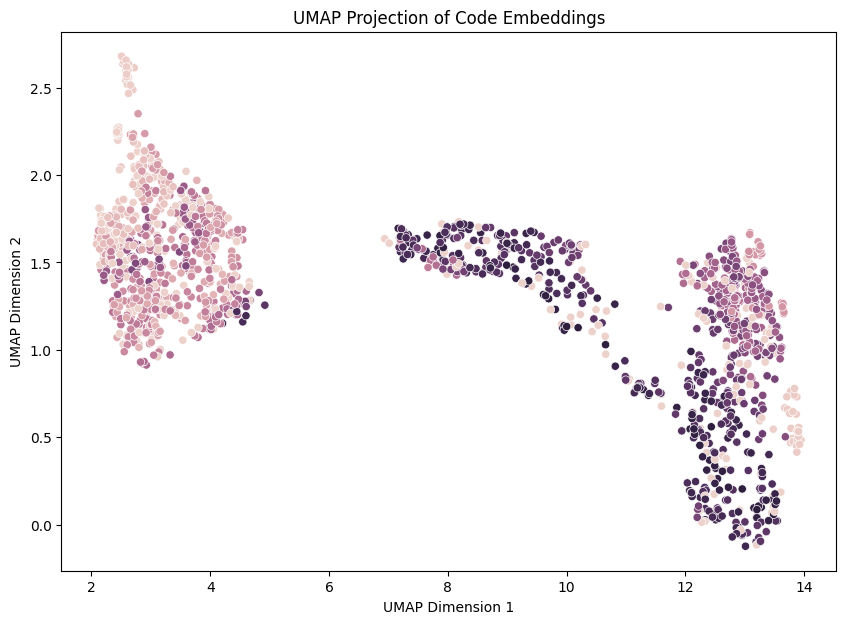

In [59]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=community_embeddings_umap[:,0], y=community_embeddings_umap[:,1], hue=community_data['cluster_label'])
plt.title('UMAP Projection of Code Embeddings')
plt.legend().remove() 
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.show()

In [60]:
distances = pairwise_distances(community_embeddings_umap, metric='cosine')
print("Pairwise distances shape:", distances.shape)
print("Max distance:", np.max(distances))
print("Min distance:", np.min(distances))
print("Mean distance:", np.mean(distances))

Pairwise distances shape: (1679, 1679)
Max distance: 0.068030775
Min distance: 0.0
Mean distance: 0.021423064


In [62]:
# dbscan_model = DBSCAN(eps=0.0001, min_samples=1, metric='cosine')
# cluster_labels = dbscan_model.fit_predict(community_embeddings_umap)
hdbscan_model = HDBSCAN(min_cluster_size=4,metric='precomputed' )
cluster_labels = hdbscan_model.fit_predict(distances.astype(np.float64))
community_data['cluster_label'] = cluster_labels

for label in np.unique(cluster_labels):
    print(f"\nCluster {label} summaries:")
    cluster_descriptions = community_data[community_data['cluster_label'] == label]['code_description'].tolist()
    combined_description = "\n".join(cluster_descriptions)
    # summary1 = summarize_code_description01(combined_description)
    # summary2 = summarize_code_description02(combined_description)
    # print(f"Summary 1: {summary1}")
    # print(f"Summary 2: {summary2}")
    print(f"Number of code snippets in cluster: {len(cluster_descriptions)}")


Cluster -1 summaries:
Number of code snippets in cluster: 588

Cluster 0 summaries:
Number of code snippets in cluster: 10

Cluster 1 summaries:
Number of code snippets in cluster: 31

Cluster 2 summaries:
Number of code snippets in cluster: 5

Cluster 3 summaries:
Number of code snippets in cluster: 12

Cluster 4 summaries:
Number of code snippets in cluster: 5

Cluster 5 summaries:
Number of code snippets in cluster: 7

Cluster 6 summaries:
Number of code snippets in cluster: 6

Cluster 7 summaries:
Number of code snippets in cluster: 12

Cluster 8 summaries:
Number of code snippets in cluster: 6

Cluster 9 summaries:
Number of code snippets in cluster: 13

Cluster 10 summaries:
Number of code snippets in cluster: 104

Cluster 11 summaries:
Number of code snippets in cluster: 5

Cluster 12 summaries:
Number of code snippets in cluster: 11

Cluster 13 summaries:
Number of code snippets in cluster: 11

Cluster 14 summaries:
Number of code snippets in cluster: 4

Cluster 15 summaries:


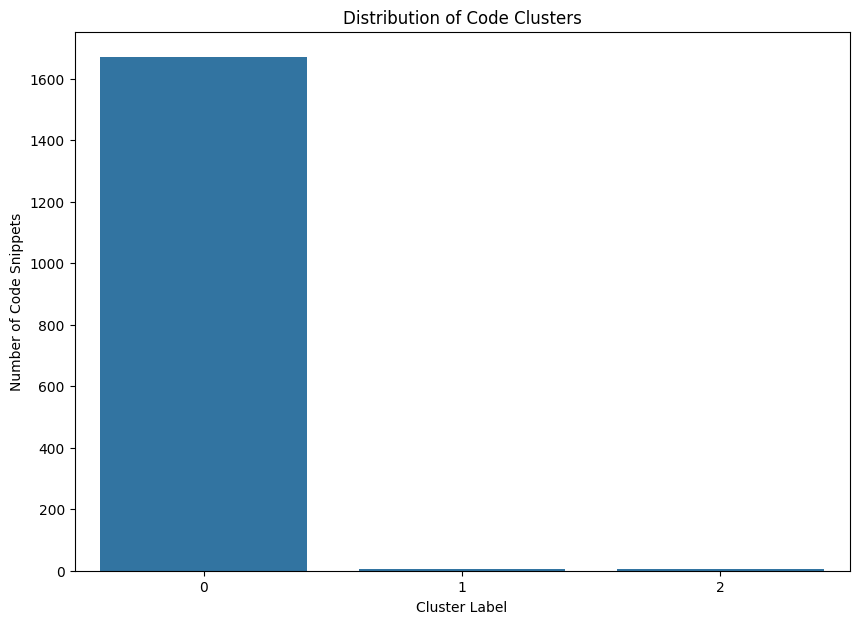

In [28]:
plt.figure(figsize=(10, 7))
sns.countplot(x='cluster_label', data=community_data)
plt.title('Distribution of Code Clusters')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Code Snippets')
plt.show()

In [46]:
import numpy as np
import hdbscan

# normalize (recommended)
emb = community_embeddings_umap / np.linalg.norm(
    community_embeddings_umap, axis=1, keepdims=True
)

clusterer = hdbscan.HDBSCAN(
    metric='cosine',
    algorithm='brute',             # MUST for cosine
    approx_min_span_tree=False,    # MUST disable sklearn tree path
    min_cluster_size=4
)

labels = clusterer.fit_predict(emb)


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


TypeError: Unknown algorithm type brute specified